# Drive mounting

In [1]:
# Connexion à Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Se placer dans le dossier du projet P9
import os
os.chdir('/content/drive/MyDrive/P9/Src')

Mounted at /content/drive


# Importing packages

In [ ]:
# 1. IMPORTS DE LA BIBLIOTHÈQUE STANDARD
import os
import glob
import json
import random
import zipfile

# 2. IMPORTS DES BIBLIOTHÈQUES TIERS (AUGMENTATION, IMAGES, DATA)
import cv2
import numpy as np
import pandas as pd
import albumentations as A      # (Bibliothèque d'augmentation d'images)
import matplotlib.pyplot as plt
from google.colab import drive  # (Spécifique à Google Colab)


# 3. DEEP LEARNING (TENSORFLOW & KERAS)
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, 
    Conv2D, 
    MaxPooling2D, 
    concatenate, 
    Conv2DTranspose, 
    BatchNormalization, 
    Activation
)
from tensorflow.keras.callbacks import (
    ModelCheckpoint, 
    EarlyStopping, 
    ReduceLROnPlateau
)


In [ ]:
# Configuration de la mémoire du GPU pour éviter le crash CUDA
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ Memory Growth activée sur {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(e)


✅ Memory Growth activée sur 1 GPU(s)


# Chargement des données

In [ ]:
isic_dir_drive = "/content/drive/MyDrive/P9/Src/Data/ISIC2018"
local_base_dir = "/content/P9/Data/ISIC2018"
zip_files = glob.glob(os.path.join(isic_dir_drive, "**/*.zip"), recursive=True)

if len(zip_files) == 0:
    print(f"❌ Aucun fichier ZIP trouvé dans {isic_dir_drive}")
else:
    print(f"📦 {len(zip_files)} fichiers ZIP trouvés. Décompression VERS LE SSD LOCAL DE COLAB...")

    for zip_path in zip_files:
        sub_folder = os.path.relpath(os.path.dirname(zip_path), isic_dir_drive)
        local_extract_dir = os.path.join(local_base_dir, sub_folder)
        os.makedirs(local_extract_dir, exist_ok=True)

        print(f"Extraction de {os.path.basename(zip_path)} dans {local_extract_dir}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(local_extract_dir)

    print(f"✅ Terminé ! Vos dossiers (test, train, validation) ont été recréés localement dans {local_base_dir}")

📦 6 fichiers ZIP trouvés. Décompression VERS LE SSD LOCAL DE COLAB...
Extraction de Test_GroundTruth.zip dans /content/P9/Data/ISIC2018/test...
Extraction de Test_Input.zip dans /content/P9/Data/ISIC2018/test...
Extraction de Training_GroundTruth.zip dans /content/P9/Data/ISIC2018/train...
Extraction de Training_Input.zip dans /content/P9/Data/ISIC2018/train...
Extraction de Validation_GroundTruth.zip dans /content/P9/Data/ISIC2018/validation...
Extraction de Validation_Input.zip dans /content/P9/Data/ISIC2018/validation...
✅ Terminé ! Vos dossiers (test, train, validation) ont été recréés localement dans /content/P9/Data/ISIC2018


# Definition des paths

In [ ]:
train_images_dir = '/content/P9/Data/ISIC2018/train/Training_Input'
train_masks_dir = '/content/P9/Data/ISIC2018/train/Training_GroundTruth'

validation_images_dir = '/content/P9/Data/ISIC2018/validation/Validation_Input'
validation_masks_dir = '/content/P9/Data/ISIC2018/validation/Validation_GroundTruth'

test_images_dir = '/content/P9/Data/ISIC2018/test/Test_Input'
test_masks_dir = '/content/P9/Data/ISIC2018/test/Test_GroundTruth'

In [6]:
# Lister et trier les fichiers pour s'assurer que l'image et le masque correspondent
train_images_paths = sorted(glob.glob(os.path.join(train_images_dir, '*.jpg')))
train_masks_paths = sorted(glob.glob(os.path.join(train_masks_dir, '*.png')))
print(f"Nombre d'images d'entraînement : {len(train_images_paths)}")
print(f"Nombre de masques d'entraînement : {len(train_masks_paths)}")

validation_images_paths = sorted(glob.glob(os.path.join(validation_images_dir, '*.jpg')))
validation_masks_paths = sorted(glob.glob(os.path.join(validation_masks_dir, '*.png')))
print(f"Nombre d'images de validation : {len(validation_images_paths)}")
print(f"Nombre de masques de validation : {len(validation_masks_paths)}")

test_images_paths = sorted(glob.glob(os.path.join(test_images_dir, '*.jpg')))
test_masks_paths = sorted(glob.glob(os.path.join(test_masks_dir, '*.png')))
print(f"Nombre d'images de test : {len(test_images_paths)}")
print(f"Nombre de masques de test : {len(test_masks_paths)}")


Nombre d'images d'entraînement : 2594
Nombre de masques d'entraînement : 2594
Nombre d'images de validation : 100
Nombre de masques de validation : 100
Nombre d'images de test : 1000
Nombre de masques de test : 1000


# Data loaders

In [ ]:
IMG_HEIGHT = 256
IMG_WIDTH = 256
BATCH_SIZE = 32

class ISIC2018Generator(tf.keras.utils.Sequence):
    def __init__(self, img_paths, mask_paths, batch_size=BATCH_SIZE, img_size=(IMG_HEIGHT, IMG_WIDTH), augment=False):
        self.img_paths = list(img_paths)
        self.mask_paths = list(mask_paths)
        self.batch_size = batch_size
        self.img_size = img_size
        self.augment = augment
        
        # Pipeline d'augmentation d'images avec Albumentations
        # Ces transformations sont idéales pour des lésions cutanées
        self.aug_pipeline = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=45, p=0.5),
            A.RandomBrightnessContrast(p=0.2),
        ]) if augment else None

    def __len__(self):
        # Nombre de batchs par époque
        return int(np.ceil(len(self.img_paths) / self.batch_size))

    def __getitem__(self, idx):
        # Récupération des chemins pour le lot (batch) actuel
        batch_img_paths = self.img_paths[idx * self.batch_size : (idx + 1) * self.batch_size]
        batch_mask_paths = self.mask_paths[idx * self.batch_size : (idx + 1) * self.batch_size]
        
        # Initialisation des tenseurs contenant les images et masques du batch
        x = np.zeros((len(batch_img_paths), self.img_size[0], self.img_size[1], 3), dtype="float32")
        y = np.zeros((len(batch_img_paths), self.img_size[0], self.img_size[1], 1), dtype="float32")
        
        for j, (img_path, mask_path) in enumerate(zip(batch_img_paths, batch_mask_paths)):
            # 1. Lecture et redimensionnement de l'image
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (self.img_size[1], self.img_size[0]))
            
            # 2. Lecture et redimensionnement du masque
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, (self.img_size[1], self.img_size[0]), interpolation=cv2.INTER_NEAREST)
            
            # 3. Augmentation de données (Image + Masque en même temps !)
            if self.augment:
                augmented = self.aug_pipeline(image=img, mask=mask)
                img = augmented['image']
                mask = augmented['mask']
            
            # 4. Normalisation
            img = img / 255.0
            mask = mask / 255.0
            
            # Binarisation stricte du masque au cas où le redimensionnement a créé des pixels gris
            mask = np.where(mask > 0.5, 1.0, 0.0) 
            
            # 5. Stockage dans le batch
            x[j] = img
            y[j] = np.expand_dims(mask, -1)
            
        return x, y

    def on_epoch_end(self):
        # Mélanger les données à la fin de chaque époque pour éviter l'overfitting
        combined = list(zip(self.img_paths, self.mask_paths))
        random.shuffle(combined)
        shuffled = list(zip(*combined))
        if shuffled:
            self.img_paths, self.mask_paths = list(shuffled[0]), list(shuffled[1])

# --- Instanciation des Générateurs ---
# Seul le dataset d'entraînement subit l'augmentation de données !
train_dataset = ISIC2018Generator(train_images_paths, train_masks_paths, batch_size=BATCH_SIZE, augment=True)
val_dataset = ISIC2018Generator(validation_images_paths, validation_masks_paths, batch_size=BATCH_SIZE, augment=False)
test_dataset = ISIC2018Generator(test_images_paths, test_masks_paths, batch_size=BATCH_SIZE, augment=False)

print(f"✅ DataGenerators prêts ! Batch size : {BATCH_SIZE}")


✅ DataGenerators prêts ! Batch size : 32


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


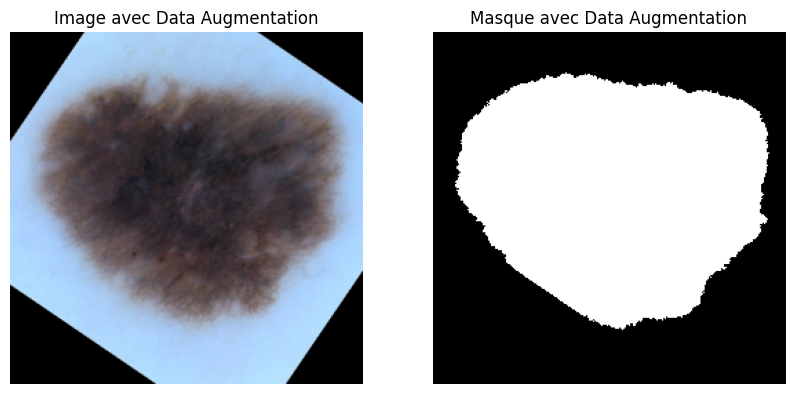

In [11]:
# Prendre le premier batch (l'index 0)
images, masks = train_dataset[0]

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Image avec Data Augmentation")
# On affiche la première image du batch
plt.imshow(images[0])
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Masque avec Data Augmentation")
# On affiche le premier masque du batch
plt.imshow(tf.squeeze(masks[0]), cmap='gray') 
plt.axis('off')

plt.show()


# Unet model

In [ ]:
# Definition du model Unet
def conv_block(input_tensor, num_filters):
    """Un bloc convolutionnel de base pour U-Net"""
    x = Conv2D(num_filters, (3, 3), padding='same')(input_tensor)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    
    x = Conv2D(num_filters, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    return x

def build_unet(input_shape=(256, 256, 3)):
    inputs = Input(input_shape)
    
    # ----- ENCODEUR (Descente) -----
    conv1 = conv_block(inputs, 64)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)
    
    conv2 = conv_block(pool1, 128)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
    
    conv3 = conv_block(pool2, 256)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)
    
    conv4 = conv_block(pool3, 512)
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)
    
    # ----- BOTTLENECK (Le fond du U) -----
    conv5 = conv_block(pool4, 1024)
    
    # ----- DÉCODEUR (Remontée avec Skip Connections) -----
    up6 = Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(conv5)
    up6 = concatenate([up6, conv4]) # Skip Connection
    conv6 = conv_block(up6, 512)
    
    up7 = Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(conv6)
    up7 = concatenate([up7, conv3]) # Skip Connection
    conv7 = conv_block(up7, 256)
    
    up8 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(conv7)
    up8 = concatenate([up8, conv2]) # Skip Connection
    conv8 = conv_block(up8, 128)
    
    up9 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(conv8)
    up9 = concatenate([up9, conv1]) # Skip Connection
    conv9 = conv_block(up9, 64)
    
    # ----- COUCHE DE SORTIE -----
    # 1 seul canal de sortie car c'est une segmentation binaire (lésion ou peau)
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(conv9)
    
    model = Model(inputs=[inputs], outputs=[outputs])
    return model

# Instanciation et affichage de l'architecture
unet_model = build_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
unet_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,055,297 (118.47 MB)

 Trainable params: 31,043,521 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

# Metriques

In [ ]:
# 1. Le coefficient Dice (Métrique de similarité)
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# 2. La Dice Loss (Ce que le modèle va essayer de minimiser)
def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

# 3. L'IoU (Intersection over Union)
def iou(y_true, y_pred, smooth=1e-6):
    intersection = K.sum(K.abs(y_true * y_pred), axis=[1,2,3])
    union = K.sum(y_true,[1,2,3]) + K.sum(y_pred,[1,2,3]) - intersection
    iou = K.mean((intersection + smooth) / (union + smooth), axis=0)
    return iou


In [14]:
# Compilation avec un learning rate de 1e-4
unet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=dice_loss, 
    metrics=[dice_coef, iou, 'accuracy']
)


# Callbacks et entrainement

In [ ]:
# 1. Définir le chemin de sauvegarde sur votre Drive
checkpoint_filepath = '/content/drive/MyDrive/P9/Src/models/best_unetAug_isic2018.h5'

# 2. Configurer les "règles" de l'entraînement
callbacks = [
    # Sauvegarde le modèle uniquement si la perte de validation (val_loss) s'améliore
    ModelCheckpoint(checkpoint_filepath, monitor='val_loss', save_best_only=True, mode='min', verbose=1),
    
    # Arrête l'entraînement si le modèle stagne pendant 10 epochs (Patience)
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    
    # Divise le Learning Rate par 2 si la perte ne descend plus (Patience 5)
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

# 3. Lancer l'entraînement
print("Début de l'entraînement de U-Net...")
history = unet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    callbacks=callbacks
)


Début de l'entraînement de U-Net...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7014 - dice_coef: 0.5005 - iou: 0.3111 - loss: 0.5019
Epoch 1: val_loss improved from None to 0.71192, saving model to /content/drive/MyDrive/P9/Src/models/best_unetAug_isic2018.h5



Epoch 1: finished saving model to /content/drive/MyDrive/P9/Src/models/best_unetAug_isic2018.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 512s 5s/step - accuracy: 0.8016 - dice_coef: 0.5829 - iou: 0.3798 - loss: 0.4196 - val_accuracy: 0.7317 - val_dice_coef: 0.2990 - val_iou: 0.1592 - val_loss: 0.7119 - learning_rate: 1.0000e-04
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9011 - dice_coef: 0.6944 - iou: 0.4628 - loss: 0.3022
Epoch 2: val_loss did not improve from 0.71192
82/82 ━━━━━━━━━━━━━━━━━━━━ 378s 5s/step - accuracy: 0.9028 - dice_coef: 0.7016 - iou: 0.4737 - loss: 0.2925 - val_accuracy: 0.7325 - val_dice_coef: 0.1723 - val_iou: 0.0860 - val_loss: 0.8278 - learning_rate: 1.0000e-04
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9117 - dice_coef: 0.7232 - iou: 0.4905 - loss: 0.2738
Epoch 3: val_loss improved from 0.71192 to 0.50292, saving model to /content/drive/MyDrive/P9/Src/models/best_unetAug_isic2018.h5



Epoch 3: finished saving model to /content/drive/MyDrive/P9/Src/models/best_unetAug_isic2018.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 391s 5s/step - accuracy: 0.9148 - dice_coef: 0.7331 - iou: 0.5046 - loss: 0.2635 - val_accuracy: 0.8163 - val_dice_coef: 0.5515 - val_iou: 0.4003 - val_loss: 0.5029 - learning_rate: 1.0000e-04
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9204 - dice_coef: 0.7541 - iou: 0.5270 - loss: 0.2461
Epoch 4: val_loss improved from 0.50292 to 0.26375, saving model to /content/drive/MyDrive/P9/Src/models/best_unetAug_isic2018.h5


...


Epoch 24: finished saving model to /content/drive/MyDrive/P9/Src/models/best_unetAug_isic2018.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 382s 5s/step - accuracy: 0.9522 - dice_coef: 0.8753 - iou: 0.7532 - loss: 0.1215 - val_accuracy: 0.9312 - val_dice_coef: 0.8800 - val_iou: 0.7831 - val_loss: 0.1362 - learning_rate: 5.0000e-05
Epoch 25/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9506 - dice_coef: 0.8723 - iou: 0.7563 - loss: 0.1267
Epoch 25: val_loss improved from 0.13623 to 0.13080, saving model to /content/drive/MyDrive/P9/Src/models/best_unetAug_isic2018.h5



Epoch 25: finished saving model to /content/drive/MyDrive/P9/Src/models/best_unetAug_isic2018.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 394s 5s/step - accuracy: 0.9532 - dice_coef: 0.8792 - iou: 0.7563 - loss: 0.1202 - val_accuracy: 0.9319 - val_dice_coef: 0.8834 - val_iou: 0.7770 - val_loss: 0.1308 - learning_rate: 5.0000e-05
Epoch 26/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9538 - dice_coef: 0.8813 - iou: 0.7608 - loss: 0.1185
Epoch 26: val_loss did not improve from 0.13080
82/82 ━━━━━━━━━━━━━━━━━━━━ 385s 5s/step - accuracy: 0.9522 - dice_coef: 0.8778 - iou: 0.7562 - loss: 0.1216 - val_accuracy: 0.9289 - val_dice_coef: 0.8819 - val_iou: 0.7875 - val_loss: 0.1364 - learning_rate: 5.0000e-05
Epoch 27/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9541 - dice_coef: 0.8788 - iou: 0.7611 - loss: 0.1224
Epoch 27: val_loss did not improve from 0.13080
82/82 ━━━━━━━━━━━━━━━━━━━━ 380s 5s/step - accuracy: 0.9520 - dice_coef: 0.8777 - iou: 0.7597 - loss: 0.1227 - val_accuracy: 0.92


Epoch 28: finished saving model to /content/drive/MyDrive/P9/Src/models/best_unetAug_isic2018.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 387s 5s/step - accuracy: 0.9533 - dice_coef: 0.8811 - iou: 0.7638 - loss: 0.1186 - val_accuracy: 0.9352 - val_dice_coef: 0.8892 - val_iou: 0.7997 - val_loss: 0.1250 - learning_rate: 5.0000e-05
Epoch 29/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9539 - dice_coef: 0.8825 - iou: 0.7654 - loss: 0.1171
Epoch 29: val_loss did not improve from 0.12497
82/82 ━━━━━━━━━━━━━━━━━━━━ 388s 5s/step - accuracy: 0.9535 - dice_coef: 0.8822 - iou: 0.7636 - loss: 0.1168 - val_accuracy: 0.9211 - val_dice_coef: 0.8513 - val_iou: 0.7443 - val_loss: 0.1440 - learning_rate: 5.0000e-05
Epoch 30/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9537 - dice_coef: 0.8862 - iou: 0.7751 - loss: 0.1139
Epoch 30: val_loss did not improve from 0.12497
82/82 ━━━━━━━━━━━━━━━━━━━━ 375s 5s/step - accuracy: 0.9531 - dice_coef: 0.8824 - iou: 0.7693 - loss: 0.1178 - val_accuracy: 0.93


Epoch 37: finished saving model to /content/drive/MyDrive/P9/Src/models/best_unetAug_isic2018.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 376s 5s/step - accuracy: 0.9569 - dice_coef: 0.8900 - iou: 0.7812 - loss: 0.1071 - val_accuracy: 0.9341 - val_dice_coef: 0.8771 - val_iou: 0.7786 - val_loss: 0.1228 - learning_rate: 2.5000e-05
Epoch 38/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9582 - dice_coef: 0.8944 - iou: 0.7872 - loss: 0.1034
Epoch 38: val_loss did not improve from 0.12283
82/82 ━━━━━━━━━━━━━━━━━━━━ 385s 5s/step - accuracy: 0.9567 - dice_coef: 0.8895 - iou: 0.7779 - loss: 0.1074 - val_accuracy: 0.9343 - val_dice_coef: 0.8628 - val_iou: 0.7792 - val_loss: 0.1268 - learning_rate: 2.5000e-05
Epoch 39/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9563 - dice_coef: 0.8860 - iou: 0.7718 - loss: 0.1112
Epoch 39: val_loss did not improve from 0.12283
82/82 ━━━━━━━━━━━━━━━━━━━━ 383s 5s/step - accuracy: 0.9565 - dice_coef: 0.8900 - iou: 0.7807 - loss: 0.1089 - val_accuracy: 0.93


Epoch 41: finished saving model to /content/drive/MyDrive/P9/Src/models/best_unetAug_isic2018.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 376s 5s/step - accuracy: 0.9575 - dice_coef: 0.8918 - iou: 0.7842 - loss: 0.1066 - val_accuracy: 0.9363 - val_dice_coef: 0.8720 - val_iou: 0.7641 - val_loss: 0.1204 - learning_rate: 2.5000e-05
Epoch 42/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9580 - dice_coef: 0.8959 - iou: 0.7891 - loss: 0.1035
Epoch 42: val_loss did not improve from 0.12044
82/82 ━━━━━━━━━━━━━━━━━━━━ 388s 5s/step - accuracy: 0.9573 - dice_coef: 0.8933 - iou: 0.7855 - loss: 0.1062 - val_accuracy: 0.9348 - val_dice_coef: 0.8800 - val_iou: 0.7980 - val_loss: 0.1282 - learning_rate: 2.5000e-05
Epoch 43/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9601 - dice_coef: 0.9016 - iou: 0.7960 - loss: 0.1000
Epoch 43: val_loss did not improve from 0.12044
82/82 ━━━━━━━━━━━━━━━━━━━━ 384s 5s/step - accuracy: 0.9592 - dice_coef: 0.8990 - iou: 0.7939 - loss: 0.1016 - val_accuracy: 0.93

Courbes d'apprentissage

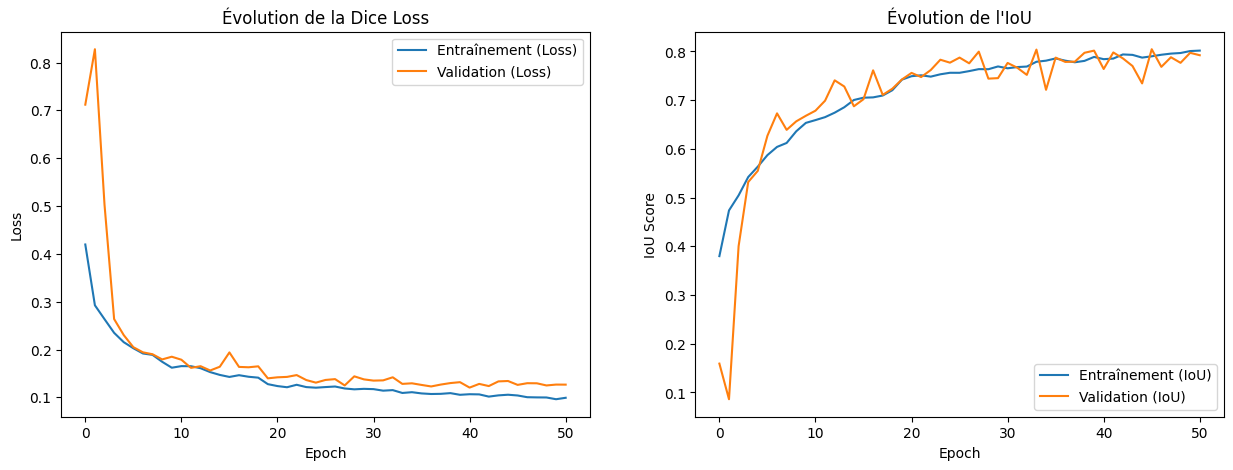

In [ ]:
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Courbe de la fonction de perte (Loss)
    ax1.plot(history.history['loss'], label='Entraînement (Loss)')
    ax1.plot(history.history['val_loss'], label='Validation (Loss)')
    ax1.set_title('Évolution de la Dice Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    
    # Courbe de l'IoU (Intersection over Union)
    ax2.plot(history.history['iou'], label='Entraînement (IoU)')
    ax2.plot(history.history['val_iou'], label='Validation (IoU)')
    ax2.set_title('Évolution de l\'IoU')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('IoU Score')
    ax2.legend()
    
    plt.show()

# Afficher les graphiques
plot_training_history(history)


# Visualisation des prédictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


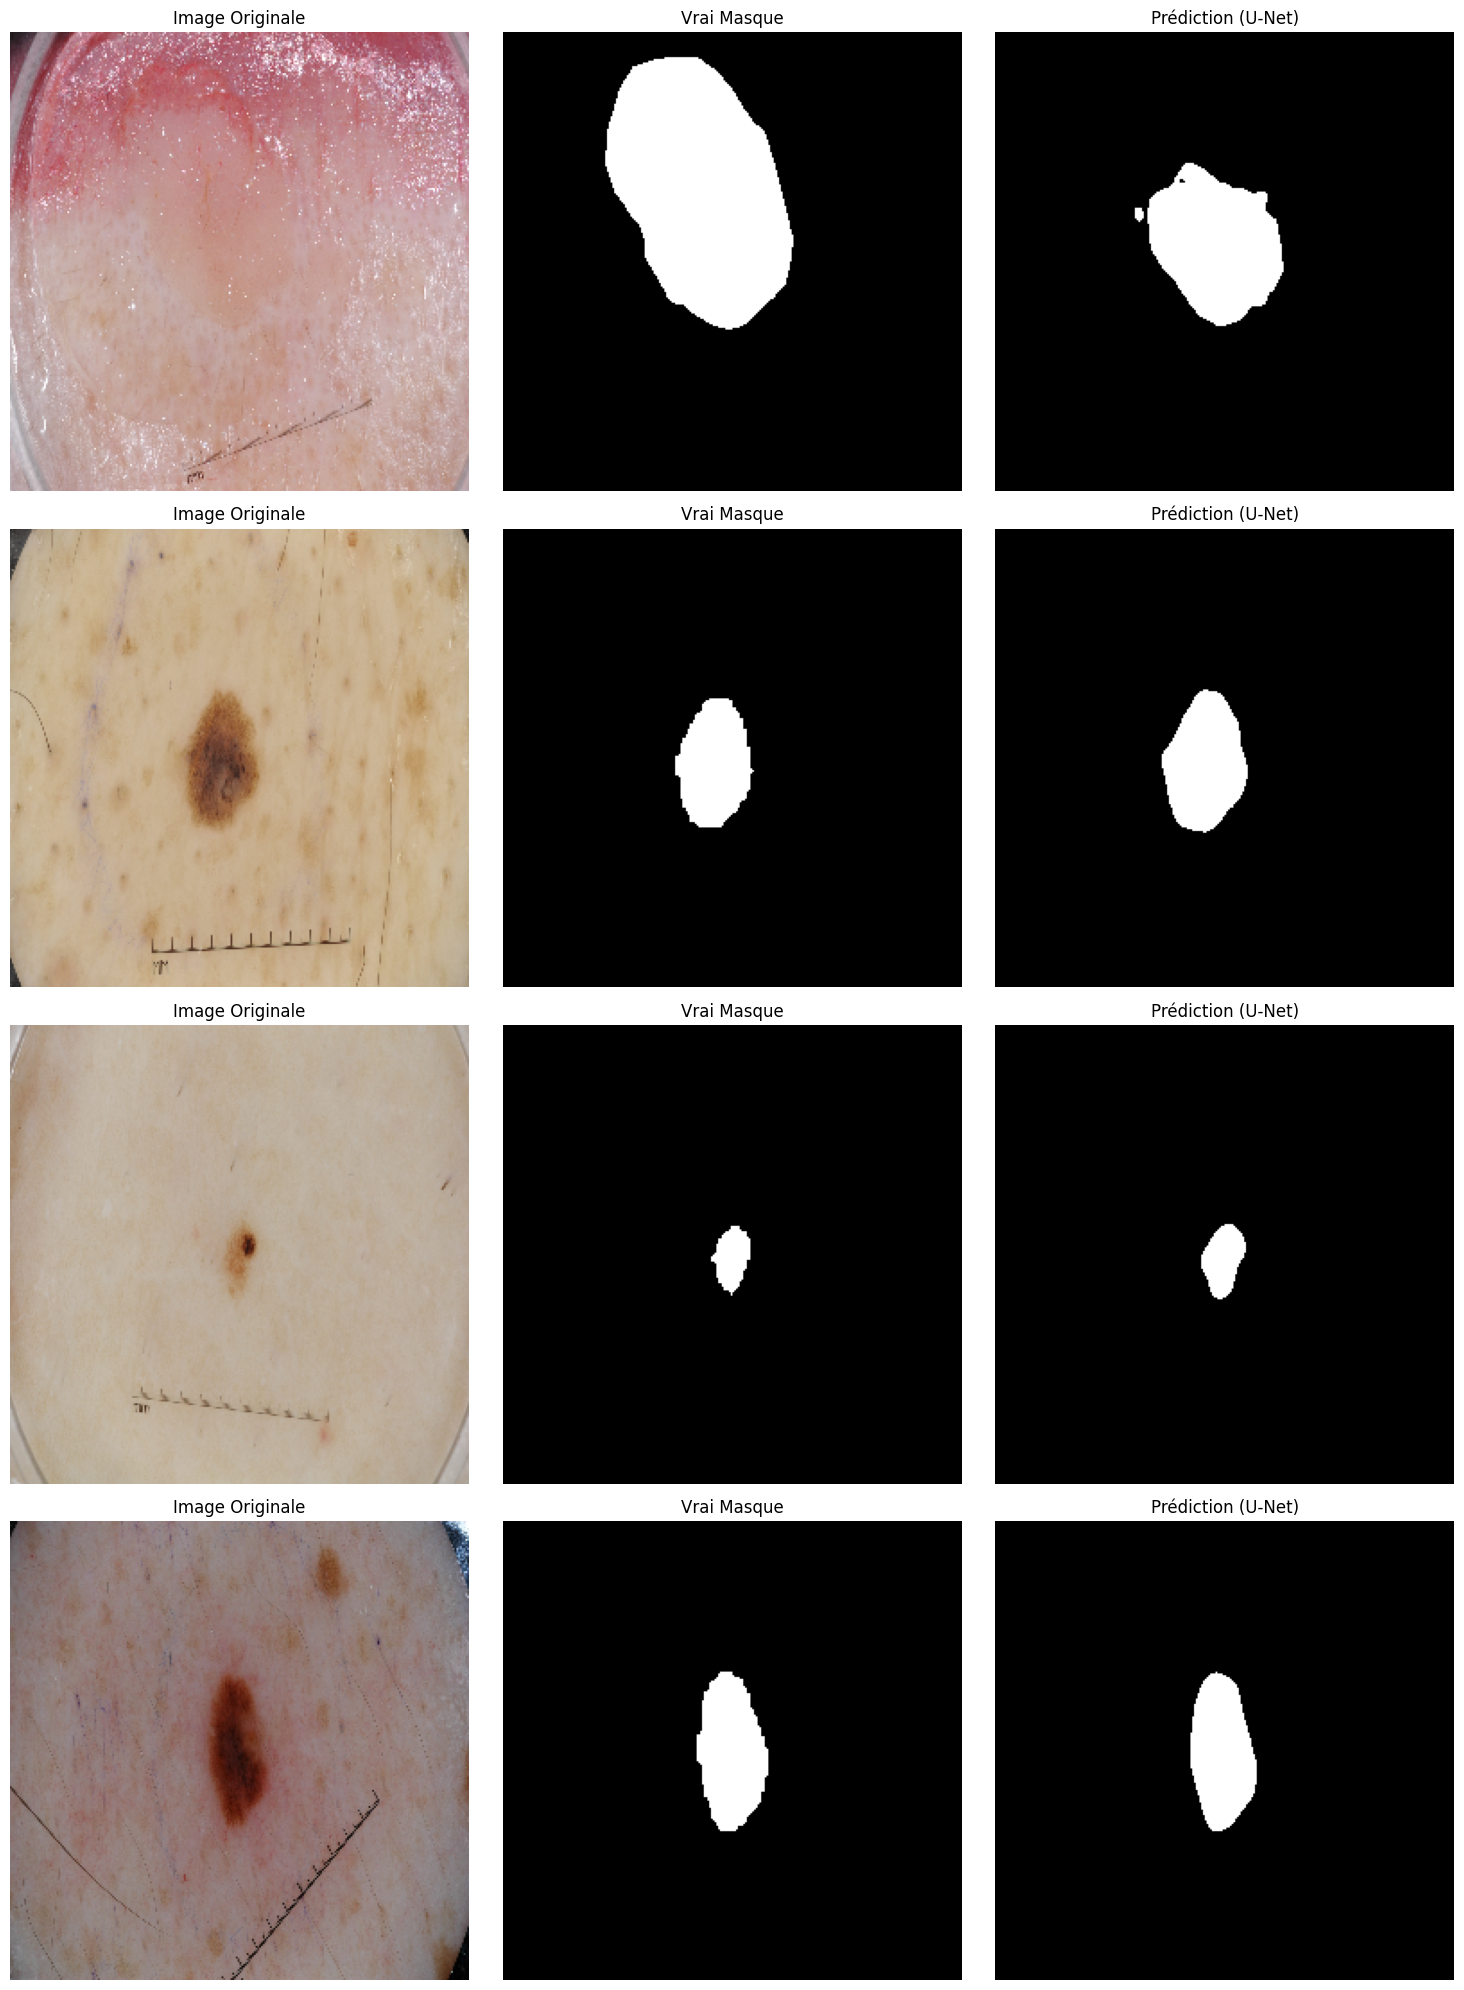

In [ ]:
def visualize_predictions(dataset, model, num_samples=3):
    # On prend le premier batch (index 0) du générateur Keras
    images, masks = dataset[0]
    
    # Le modèle génère ses prédictions sur ce lot d'images
    predictions = model.predict(images)
    
    # On s'assure de ne pas dépasser la taille du batch
    num_samples = min(num_samples, len(images))
    
    plt.figure(figsize=(15, 5 * num_samples))
    for i in range(num_samples):
        # 1. Image Originale
        plt.subplot(num_samples, 3, i*3 + 1)
        plt.title("Image Originale")
        plt.imshow(images[i])
        plt.axis("off")
        
        # 2. Masque Réel (Ground Truth)
        plt.subplot(num_samples, 3, i*3 + 2)
        plt.title("Vrai Masque")
        # squeeze() retire les dimensions inutiles (ex: 256x256x1 -> 256x256)
        plt.imshow(np.squeeze(masks[i]), cmap="gray")
        plt.axis("off")
        
        # 3. Prédiction du Modèle
        plt.subplot(num_samples, 3, i*3 + 3)
        plt.title("Prédiction (U-Net)")
        # On binarise la prédiction (tout ce qui est > 0.5 devient 1)
        pred_mask = (np.squeeze(predictions[i]) > 0.5).astype(np.float32)
        plt.imshow(pred_mask, cmap="gray")
        plt.axis("off")
        
    plt.tight_layout()
    plt.show()


# Lancer la visualisation sur les images de Test que le modèle n'a jamais vues !
visualize_predictions(test_dataset, unet_model, num_samples=4)


# Traçabilité des metriques et test

✅ Historique d'entraînement sauvegardé dans : /content/drive/MyDrive/P9/Src/Experiences/UnetAug/unetAug_training_history.csv

Évaluation sur l'ensemble de Test...
32/32 ━━━━━━━━━━━━━━━━━━━━ 87s 3s/step - accuracy: 0.9198 - dice_coef: 0.8541 - iou: 0.7616 - loss: 0.1465
loss: 0.1465
compile_metrics: 0.8541
✅ Scores de test sauvegardés dans : /content/drive/MyDrive/P9/Src/Experiences/UnetAug/unetAug_test_scores.txt
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
✅ Image de prédictions sauvegardée dans : /content/drive/MyDrive/P9/Src/Experiences/UnetAug/unetAug_test_predictions.png


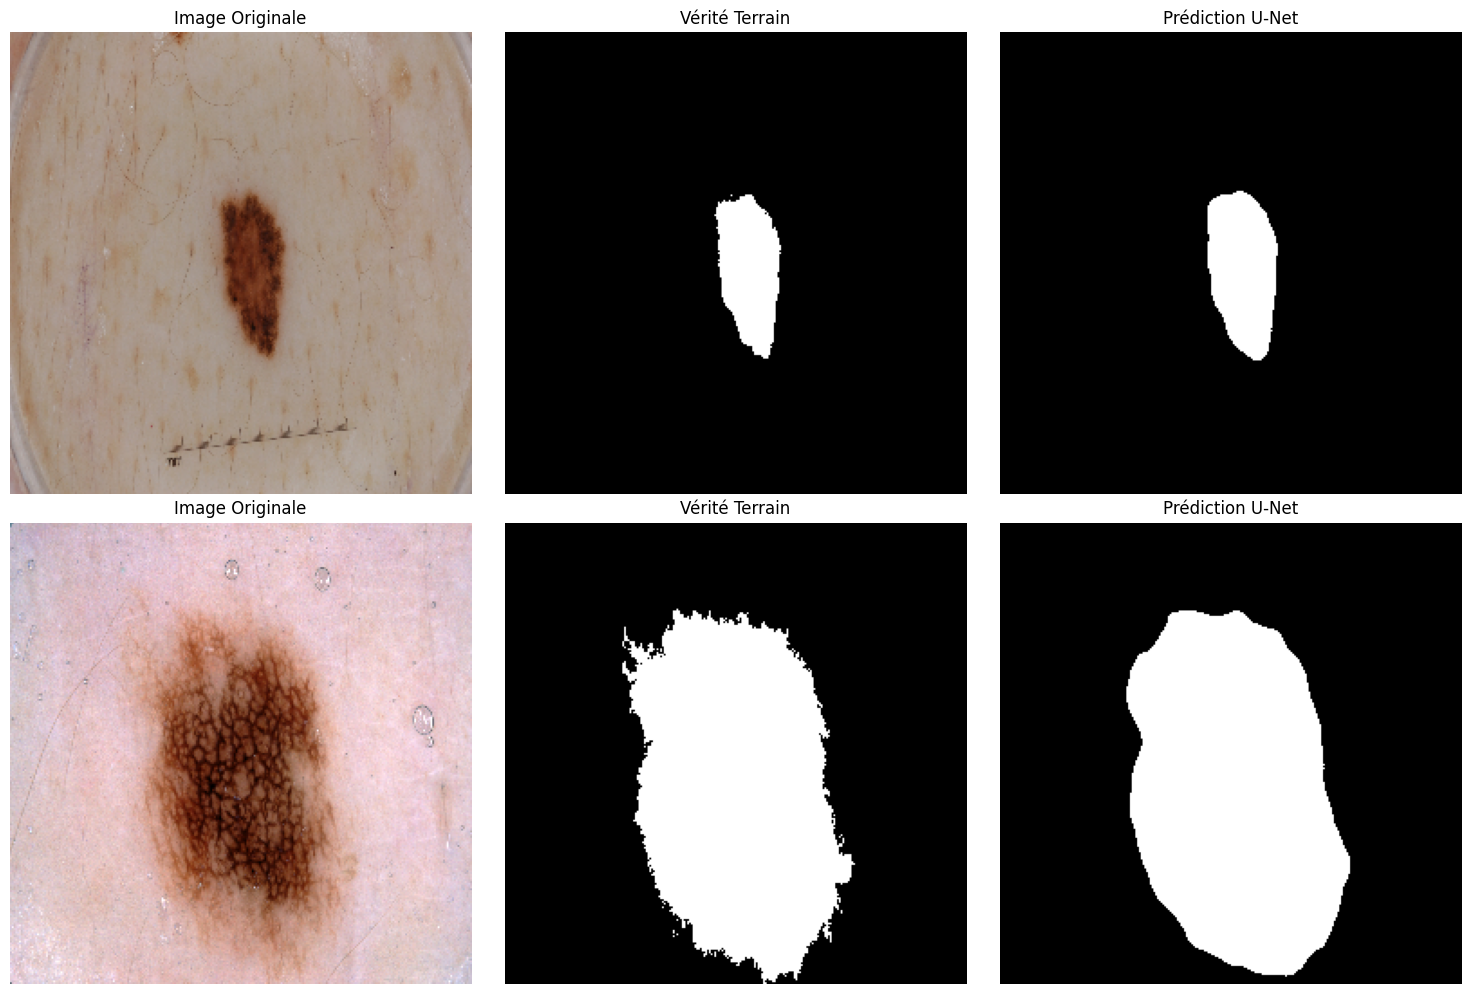

In [ ]:
exp_dir = '/content/drive/MyDrive/P9/Src/Experiences/UnetAug'
os.makedirs(exp_dir, exist_ok=True)


# 1. SAUVEGARDE DE L'HISTORIQUE D'ENTRAÎNEMENT (Loss, IoU, Dice)
history_df = pd.DataFrame(history.history)
history_csv_path = os.path.join(exp_dir, 'unetAug_training_history.csv')
history_df.to_csv(history_csv_path, index=False)
print(f"✅ Historique d'entraînement sauvegardé dans : {history_csv_path}")


# 2. ÉVALUATION ET SAUVEGARDE DES SCORES SUR LE SET DE TEST
print("\nÉvaluation sur l'ensemble de Test...")
unet_model.load_weights(checkpoint_filepath) 

# Le modèle calcule la loss, l'IoU, le Dice et l'Accuracy sur le dataset de test
test_results = unet_model.evaluate(test_dataset, verbose=1)

# Les noms des métriques correspondent à l'ordre défini lors de la compilation
metrics_names = unet_model.metrics_names 

# Sauvegarde dans un fichier texte
test_scores_path = os.path.join(exp_dir, 'unetAug_test_scores.txt')
with open(test_scores_path, 'w') as f:
    f.write("=== RÉSULTATS DE U-NET SUR ISIC 2018 (TEST SET) ===\n")
    for name, score in zip(metrics_names, test_results):
        f.write(f"{name}: {score:.4f}\n")
        print(f"{name}: {score:.4f}")
        
print(f"✅ Scores de test sauvegardés dans : {test_scores_path}")


# 3. SAUVEGARDE DES PRÉDICTIONS VISUELLES
images, masks = test_dataset[0]
predictions = unet_model.predict(images)
preds_bin = (predictions > 0.5).astype(np.float32)
plt.figure(figsize=(15, 10))
# On limite à 2 exemples
num_samples = min(2, len(images))
for i in range(num_samples): 
    # Image Originale
    plt.subplot(num_samples, 3, i*3 + 1)
    plt.title("Image Originale")
    plt.imshow(images[i])
    plt.axis('off')
    
    # Vérité Terrain
    plt.subplot(num_samples, 3, i*3 + 2)
    plt.title("Vérité Terrain")
    plt.imshow(tf.squeeze(masks[i]), cmap='gray')
    plt.axis('off')
    
    # Prédiction U-Net
    plt.subplot(num_samples, 3, i*3 + 3)
    plt.title("Prédiction U-Net")
    plt.imshow(tf.squeeze(preds_bin[i]), cmap='gray')
    plt.axis('off')

plt.tight_layout()
predictions_img_path = os.path.join(exp_dir, 'unetAug_test_predictions.png')
plt.savefig(predictions_img_path)
print(f"✅ Image de prédictions sauvegardée dans : {predictions_img_path}")
plt.show()